## Implement a L-layer neural network
parameters: 
$$
W_1, b_1, W_2, b_2, ..., W_L, b_L
$$

hyperparameters: 
- learning rate
- number of iterations
- number of hidden layers (L)
- number of hidden units ($n_1, n_2, ..., n_L$)
- activation function in each layer

In [1]:
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy
import scipy.io
from PIL import Image
from scipy import ndimage
from numpy import linalg as LA

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Data Exploration

In [2]:
def load_cat_data():
    train_dataset = h5py.File('datasets/train_catvnoncat.h5', "r")
    train_set_x_orig = np.array(train_dataset["train_set_x"][:]) # your train set features
    train_set_y_orig = np.array(train_dataset["train_set_y"][:]) # your train set labels

    test_dataset = h5py.File('datasets/test_catvnoncat.h5', "r")
    test_set_x_orig = np.array(test_dataset["test_set_x"][:]) # your test set features
    test_set_y_orig = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
    test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))
    
    return train_set_x_orig, train_set_y_orig, test_set_x_orig, test_set_y_orig, classes


y = 1. It's a cat picture.


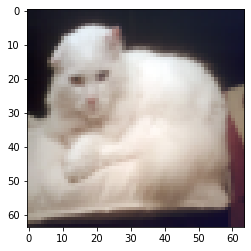

In [3]:
train_x_orig, train_y, test_x_orig, test_y, classes = load_cat_data()
# Example of a picture
index = 13
plt.imshow(train_x_orig[index])
print ("y = " + str(train_y[0,index]) + ". It's a " + classes[train_y[0,index]].decode("utf-8") +  " picture.")

In [4]:
# Explore your dataset 
m_train = train_x_orig.shape[0]
num_px = train_x_orig.shape[1]
m_test = test_x_orig.shape[0]

print ("Number of training examples: " + str(m_train))
print ("Number of testing examples: " + str(m_test))
print ("Each image is of size: (" + str(num_px) + ", " + str(num_px) + ", 3)")
print ("train_x_orig shape: " + str(train_x_orig.shape))
print ("train_y shape: " + str(train_y.shape))
print ("test_x_orig shape: " + str(test_x_orig.shape))
print ("test_y shape: " + str(test_y.shape))

Number of training examples: 209
Number of testing examples: 50
Each image is of size: (64, 64, 3)
train_x_orig shape: (209, 64, 64, 3)
train_y shape: (1, 209)
test_x_orig shape: (50, 64, 64, 3)
test_y shape: (1, 50)


In [5]:
# Reshape the training and test examples
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0], -1).T   # The "-1" makes reshape flatten the remaining dimensions
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1).T

# Standardize data to have feature values between 0 and 1.
train_x = train_x_flatten/255.
test_x = test_x_flatten/255.

print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

train_x's shape: (12288, 209)
test_x's shape: (12288, 50)


# Simple Model

### Summary of learning process
- initialize parameters
- compute loss using forward function (store A, Z when forwarding)
- by doing back propagation, compute gradients of parameters with respect to calculated loss (using A,Z stored in forward propagation and params)
- compute cost function
- update parameters according to gradients calculated in back propagation (gradien descent)
- repeat steps 2 to 5 for the number of iterations

In [6]:
class DeepNN:
    
    def __init__(self, layer_dims, actv_funcs):
        
        self.layer_dims = layer_dims
        self.L = len(self.layer_dims) # number of layers
        self.actv_funcs = actv_funcs # len = L-1

        assert not len(actv_funcs)>(self.L-1), "Too many activation function is given."
        assert not len(actv_funcs)<(self.L-1), "Too few activation function is given."
        assert not self.layer_dims[self.L-1]!=1, "This network only supports single layer output."
        
        self.params = self.create_parameters()     
        self.costs = []
        
    def create_parameters(self): 
        # np.random.seed(seed=11)
        params = {}
        for l in range(1, self.L):
            if self.actv_funcs[l-1]=="relu":
                params["W"+str(l)] = 2 * np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
            elif self.actv_funcs[l-1]=="sigmoid":
                params["W"+str(l)] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
            else: 
                params["W"+str(l)] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
                
            params["b"+str(l)] = np.zeros((self.layer_dims[l], 1))
            print("W", l, " shape: ", params["W"+str(l)].shape)
            print("b", l, " shape: ", params["b"+str(l)].shape)

        return params

    def forward(self, X):
        linear_actvs = {}
        # X.shape should be (layer_dim[0], m)
        # m = #training examples
        linear_actvs["A0"] = X

        for l in range(1, self.L): 
            linear_actvs["Z"+str(l)] = np.dot(self.params["W"+str(l)], linear_actvs["A"+str(l-1)]) + self.params["b"+str(l)]
            linear_actvs["A"+str(l)] = self.act_func(linear_actvs["Z"+str(l)], func = self.actv_funcs[l-1])

        return linear_actvs
        
    def backward(self, Y, linear_actvs, loss_func="add later"):
        grads = {}
        m = Y.shape[1]
        
        # dA[L-1] = -Y / A_L-1 + (1-Y) / (1-A_L-1)
        grads["dA"+str(self.L-1)] = np.divide(-Y, linear_actvs["A"+str(self.L-1)]) + np.divide(1-Y, 1 - linear_actvs["A"+str(self.L-1)])
        # dZ[L-1] = dA[L-1] * G`
        grads["dZ"+str(self.L-1)] = np.multiply(grads["dA"+str(self.L-1)], self.act_func(linear_actvs["Z"+str(self.L-1)], func=self.actv_funcs[self.L-2], grad=True))

        # from l = L to l = 1
        for l in range(self.L-1, 0, -1):
            # dW[l] = 1/m * dZ[l] . A[l-1] 
            grads["dW"+str(l)]   = 1/m * np.dot(grads["dZ"+str(l)], linear_actvs["A"+str(l-1)].T)
            # db[l] = 1/m * np sum (dZ_l)
            grads["db"+str(l)]   = 1/m * np.sum(grads["dZ"+str(l)], axis=1, keepdims=True)
            if l!=1:
                # dA[l-1] = (W[l]).T . dZ[l]
                grads["dA"+str(l-1)] = np.dot((self.params["W"+str(l)]).T, grads["dZ"+str(l)])
                # dZ[l-1] = dA[l-1] * g`
                grads["dZ"+str(l-1)] = np.multiply(grads["dA"+str(l-1)], self.act_func(linear_actvs["Z"+str(l-1)], func=self.actv_funcs[l-2], grad=True))

        return grads
    
    def compute_cost(self, Y, linear_actvs, is_debug=False):
        m = Y.shape[1]
        AL = linear_actvs["A"+str(self.L-1)]

        cost = -1/m * (np.nansum(np.multiply(Y, np.log(AL))) + np.nansum(np.multiply((1-Y), np.log(1-AL))))
        cost = np.squeeze(cost)

        return cost

    def update_params(self, grads, lr):
        for l in range(1, self.L):
            self.params["W"+str(l)] = self.params["W"+str(l)] - lr * grads["dW"+str(l)]
            self.params["b"+str(l)] = self.params["b"+str(l)] - lr * grads["db"+str(l)]
                
    def train(self, X, Y, num_iterations, lr, is_debug=False):
        self.learning_rate = lr
        m = X.shape[1] # ?
        assert not X.shape[0]!=self.layer_dims[0], "given Input X doesnt match the Input Layer size."
        assert not X.shape[1]!=Y.shape[1], "Number of inputs and outputs doesnt match."
        assert not Y.shape[0]!= 1, "This network only supports single output."
        
        for i in range(num_iterations):
            linear_actvs = self.forward(X)
            grads = self.backward(Y, linear_actvs)
            cost = self.compute_cost(Y, linear_actvs, is_debug)
            self.update_params(grads, lr)
            
            if i % 100 == 0 or i == num_iterations-1:
               print("cost after iteration ", i, ": ", cost)
        
            if i % 50 == 0 or i == num_iterations-1:
                self.costs.append(cost)
                

    def predict(self, X, y):
        assert not X.shape[1]!=y.shape[1], "Number of inputs and outputs doesnt match."
        assert not X.shape[0]!=self.layer_dims[0], "given Input X doesnt match the Input Layer size."
        assert not y.shape[0]!=1, "This network only supports single layer output."

        m = X.shape[1]
        n = len(self.params) // 2 
        p = np.zeros((1,m))
        
        linear_actvs = self.forward(X)
        yhat = linear_actvs["A"+str(n)]

        for i in range(0, yhat.shape[1]):
            if yhat[0,i] > 0.5:
                p[0,i] = 1
            else:
                p[0,i] = 0
    
        print("Accuracy: "  + str(np.sum((p == y)/m)))

        return p
    
    def act_func(self, Z, func = "relu", grad=False):
        if func == "relu":
            if grad==False:
                return np.maximum(Z, 0)
            else:
                return np.where(Z <= 0, 0, 1)
            
        elif func == "sigmoid":
            if grad==False:
                return 1/(1+np.exp(-Z))
            else: 
                s = 1/(1+np.exp(-Z))
                return s * (1-s)
        else:
            assert False, "Activation function "+func+" is not supported."
            
    def plot_lr(self):
        costs = np.squeeze(self.costs)
        plt.plot(costs)
        plt.ylabel('cost')
        plt.xlabel('iterations (x1,000)')
        plt.title("Learning rate =" + str(self.learning_rate))
        plt.show()

W 1  shape:  (20, 12288)
b 1  shape:  (20, 1)
W 2  shape:  (10, 20)
b 2  shape:  (10, 1)
W 3  shape:  (5, 10)
b 3  shape:  (5, 1)
W 4  shape:  (1, 5)
b 4  shape:  (1, 1)
cost after iteration  0 :  0.8585316299843091
cost after iteration  100 :  0.6682736889238705
cost after iteration  200 :  0.6407978420242438
cost after iteration  300 :  0.6047275591790141
cost after iteration  400 :  0.5630032877457763
cost after iteration  500 :  0.534567091854557
cost after iteration  600 :  0.49446289109791125
cost after iteration  700 :  0.4505694905833384
cost after iteration  800 :  0.4194452330236148
cost after iteration  900 :  0.3834338717006896
cost after iteration  1000 :  0.34998673523730883
cost after iteration  1100 :  0.3222892989668766
cost after iteration  1200 :  0.25286403655216755
cost after iteration  1300 :  0.19419856646339562
cost after iteration  1400 :  0.15587594487609546
cost after iteration  1499 :  0.11512607153065121


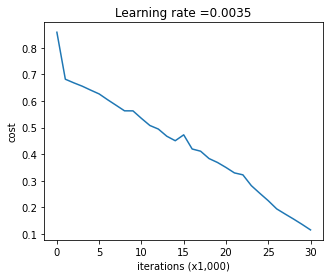

On the training set:
Accuracy: 0.9808612440191385
On the test set:
Accuracy: 0.72


In [397]:
activation_funcs = ["relu", "relu", "relu", "sigmoid"]
dnn = DeepNN([12288, 20, 10, 5, 1], activation_funcs)
dnn.train(train_x, train_y, 1500, 0.0035)

dnn.plot_lr()
print ("On the training set:")
predictions_train = dnn.predict(train_x, train_y)
print ("On the test set:")
predictions_test = dnn.predict(test_x, test_y)

### Nan bug and overflow error:

example of overflow in last layer activations, so A[L-1] rounds to Zero and causes dividing by zero in backward function, 
which can be avoided if you use simplifed (simplified by calculus) formula:
dZ[L-1] = A[L-1] - Y 

**note that here L-1 is the last layer

In [363]:
def sigmoid(x):
    s = 1/(1+np.exp(-x))
    return s

sigmoid(-3022.56387003), np.exp(3022.56387003)

F:\apps\Anaconda\lib\site-packages\ipykernel_launcher.py:2: RuntimeWarning: overflow encountered in exp
  
F:\apps\Anaconda\lib\site-packages\ipykernel_launcher.py:5: RuntimeWarning: overflow encountered in exp
  """


(0.0, inf)

# L2 Regularization

In [7]:
import sys

In [129]:
class DeepNN:
    
    def __init__(self, layer_dims, actv_funcs):
        
        self.layer_dims = layer_dims
        self.L = len(self.layer_dims) # number of layers
        self.actv_funcs = actv_funcs # len = L-1

        assert not len(actv_funcs)>(self.L-1), "Too many activation function is given."
        assert not len(actv_funcs)<(self.L-1), "Too few activation function is given."
        assert not self.layer_dims[self.L-1]!=1, "This network only supports single layer output."
        
        self.params = self.create_parameters()     
        self.costs = []
        
    def create_parameters(self): 
        # np.random.seed(seed=11)
        params = {}
        for l in range(1, self.L):
            if self.actv_funcs[l-1]=="relu":
                params["W"+str(l)] = 2 * np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
            elif self.actv_funcs[l-1]=="sigmoid":
                params["W"+str(l)] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
            else: 
                params["W"+str(l)] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
                
            params["b"+str(l)] = np.zeros((self.layer_dims[l], 1))
            print("W", l, " shape: ", params["W"+str(l)].shape)
            print("b", l, " shape: ", params["b"+str(l)].shape)

        return params

    def forward_test(self, X):
        linear_actvs = {}
        linear_actvs["A0"] = X
        for l in range(1, self.L): 
            linear_actvs["Z"+str(l)] = np.dot(self.params["W"+str(l)], linear_actvs["A"+str(l-1)]) + self.params["b"+str(l)]
            linear_actvs["A"+str(l)] = self.act_func(linear_actvs["Z"+str(l)], func = self.actv_funcs[l-1])

        return linear_actvs
    
    def forward(self, X, iter_num=-1):
        linear_actvs = {}
        # X.shape should be (layer_dim[0], m)
        # m = #training examples
        linear_actvs["A0"] = X

        for l in range(1, self.L): 
            linear_actvs["Z"+str(l)] = np.dot(self.params["W"+str(l)], linear_actvs["A"+str(l-1)]) + self.params["b"+str(l)]
            linear_actvs["A"+str(l)] = self.act_func(linear_actvs["Z"+str(l)], func = self.actv_funcs[l-1])

        return linear_actvs
        
    def backward(self, Y, linear_actvs, loss_func="add later"):
        grads = {}
        m = Y.shape[1]
        
        """""
        # dA[L-1] = -Y / A_L-1 + (1-Y) / (1-A_L-1)
        grads["dA"+str(self.L-1)] = np.divide(-Y, linear_actvs["A"+str(self.L-1)]) + np.divide(1-Y, 1 - linear_actvs["A"+str(self.L-1)])
        # dZ[L-1] = dA[L-1] * G`[L-1]
        grads["dZ"+str(self.L-1)] = np.multiply(grads["dA"+str(self.L-1)], self.act_func(linear_actvs["Z"+str(self.L-1)], func=self.actv_funcs[self.L-2], grad=True))
        """""
        
        # ***********
        # using the above equations, case of A[L-1] = 0 might have happend (because of large Z and using sigmoid and rounding number to 0 (overflow))
        # then using the above equation causes /0 error and creates Nan
        # to avoid that, use the simplified version:
        # dZ[L-1] = A[L-1] - Y
        grads["dZ"+str(self.L-1)] = linear_actvs["A"+str(self.L-1)] - Y
        
        # from l = L to l = 1
        for l in range(self.L-1, 0, -1):
            if self.regularization == "L2":
                # dW[l] = 1/m * dZ[l] . A[l-1] + lambda/m * W[l]
                grads["dW"+str(l)]   = 1/m * np.dot(grads["dZ"+str(l)], linear_actvs["A"+str(l-1)].T) + ((self.reg_param/m) * self.params["W"+str(l)])
                # db[l] = 1/m * np sum (dZ_l)
                grads["db"+str(l)]   = 1/m * np.sum(grads["dZ"+str(l)], axis=1, keepdims=True)
                if l!=1:
                    # dA[l-1] = (W[l]).T . dZ[l]
                    grads["dA"+str(l-1)] = np.dot((self.params["W"+str(l)]).T, grads["dZ"+str(l)])
                    # dZ[l-1] = dA[l-1] * g`
                    grads["dZ"+str(l-1)] = np.multiply(grads["dA"+str(l-1)], self.act_func(linear_actvs["Z"+str(l-1)], func=self.actv_funcs[l-2], grad=True))

            else:
                # dW[l] = 1/m * dZ[l] . A[l-1] 
                grads["dW"+str(l)]   = 1/m * np.dot(grads["dZ"+str(l)], linear_actvs["A"+str(l-1)].T)
                # db[l] = 1/m * np sum (dZ_l)
                grads["db"+str(l)]   = 1/m * np.sum(grads["dZ"+str(l)], axis=1, keepdims=True)
                if l!=1:
                    # dA[l-1] = (W[l]).T . dZ[l]
                    grads["dA"+str(l-1)] = np.dot((self.params["W"+str(l)]).T, grads["dZ"+str(l)])
                    # dZ[l-1] = dA[l-1] * g`
                    grads["dZ"+str(l-1)] = np.multiply(grads["dA"+str(l-1)], self.act_func(linear_actvs["Z"+str(l-1)], func=self.actv_funcs[l-2], grad=True))

        return grads
    
    def compute_cost(self, Y, linear_actvs, iter_num, is_debug=False):
        m = Y.shape[1]
        AL = linear_actvs["A"+str(self.L-1)]
            
        cost = (-1/m) * (np.nansum(np.multiply(Y, np.log(AL))) + np.nansum(np.multiply((1-Y), np.log(1-AL)))) 

        if self.regularization == "L2":
            reg_cost = 0
            for l in range(self.L-1, 0, -1):
                reg_cost += np.nansum(np.square(self.params['W'+str(l)]))

            cost = cost + self.reg_param/(2*m) * reg_cost
            cost = np.squeeze(cost)

        return cost

    def update_params(self, grads, lr):
        for l in range(1, self.L):
            self.params["W"+str(l)] = self.params["W"+str(l)] - lr * grads["dW"+str(l)]
            self.params["b"+str(l)] = self.params["b"+str(l)] - lr * grads["db"+str(l)]
                
    def train(self, X, Y, num_iterations, lr, regularization = "", reg_param = 0, keep_probs = [], is_debug=False):
        self.reg_param = reg_param
        self.learning_rate = lr
        self.regularization = regularization
        if regularization == "L2":
            assert reg_param != 0, "L2 regularization requires reg_param"
            assert len(keep_probs)==0, "Cannot use dropout and L2 at the same time"
        elif regularization == "dropout":
            assert len(keep_probs)>0, "Dropout regularization requires Keep_prob list"
            assert reg_param == 0, "Cannot use dropout and L2 at the same time"
        
        m = X.shape[1] # ?
        assert not X.shape[0]!=self.layer_dims[0], "given Input X doesnt match the Input Layer size."
        assert not X.shape[1]!=Y.shape[1], "Number of inputs and outputs doesnt match."
        assert not Y.shape[0]!= 1, "This network only supports single output."
        
        for i in range(num_iterations):
            
            linear_actvs = self.forward(X, i)
            grads = self.backward(Y, linear_actvs)
            cost = self.compute_cost(Y, linear_actvs, i, is_debug)
            self.update_params(grads, lr)
            
            if i % 1000 == 0 or i == num_iterations-1:
                print("cost after iteration ", i, ": ", cost)
        
            if i % 1000 == 0 or i == num_iterations-1:
                self.costs.append(cost)
                
                
    def predict(self, X, y):
        assert not X.shape[1]!=y.shape[1], "Number of inputs and outputs doesnt match."
        assert not X.shape[0]!=self.layer_dims[0], "given Input X doesnt match the Input Layer size."
        assert not y.shape[0]!=1, "This network only supports single layer output."

        m = X.shape[1]
        n = len(self.params) // 2 
        p = np.zeros((1,m))
        
        linear_actvs = self.forward(X)
        yhat = linear_actvs["A"+str(n)]

        for i in range(0, yhat.shape[1]):
            if yhat[0,i] > 0.5:
                p[0,i] = 1
            else:
                p[0,i] = 0
    
        print("Accuracy: "  + str(np.sum((p == y)/m)))

        return p
    
    def act_func(self, Z, func = "relu", grad=False):
        if func == "relu":
            if grad==False:
                return np.maximum(Z, 0)
            else:
                return np.where(Z <= 0, 0, 1)
            
        elif func == "sigmoid":
            if grad==False:
                res = 1/(1+np.exp(-Z))
                return res
            else: 
                s = 1/(1+np.exp(-Z))
                return s * (1-s)
        else:
            assert False, "Activation function "+func+" is not supported."\
            
    def plot_lr(self):
        costs = np.squeeze(self.costs)
        plt.plot(costs)
        plt.ylabel('cost')
        plt.xlabel('iterations (x1,000)')
        plt.title("Learning rate =" + str(self.learning_rate))
        plt.show()

## Data

In [118]:
def predict_plot(model, X):
    # Predict using forward propagation and a classification threshold of 0.5
    linear_actvs = model.forward_test(X)
    al = linear_actvs["A"+str(model.L-1)]
    predictions = (al>0.5)
    return predictions

def plot_decision_boundary(model, X, y):
    # Set min and max values and give it some padding
    x_min, x_max = X[0, :].min() - 1, X[0, :].max() + 1
    y_min, y_max = X[1, :].min() - 1, X[1, :].max() + 1
    h = 0.01
    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    # Predict the function value for the whole grid
    Z = model(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    # Plot the contour and training examples
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral)
    plt.ylabel('x2')
    plt.xlabel('x1')
    plt.scatter(X[0, :], X[1, :], c=y, cmap=plt.cm.Spectral)
    plt.show()

In [119]:
def load_2D_dataset():
    data = scipy.io.loadmat('datasets/2D_data.mat')
    train_X = data['X'].T
    train_Y = data['y'].T
    test_X = data['Xval'].T
    test_Y = data['yval'].T

    plt.scatter(train_X[0, :], train_X[1, :], c=train_Y, s=40, cmap=plt.cm.Spectral);
    
    return train_X, train_Y, test_X, test_Y

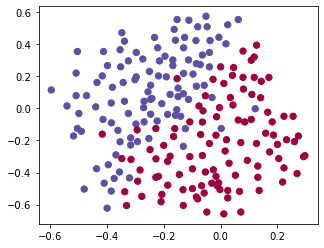

In [120]:
train_x, train_y, test_x, test_y = load_2D_dataset()

In [121]:
train_x.shape

(2, 211)

## No L2 regularization:

W 1  shape:  (20, 2)
b 1  shape:  (20, 1)
W 2  shape:  (3, 20)
b 2  shape:  (3, 1)
W 3  shape:  (1, 3)
b 3  shape:  (1, 1)
cost after iteration  0 :  0.6754693923631451
cost after iteration  1000 :  0.2019072774207511
cost after iteration  2000 :  0.20045427859972248
cost after iteration  3000 :  0.17904343893944594
cost after iteration  4000 :  0.1731397823722749
cost after iteration  5000 :  0.16529306599880594
cost after iteration  6000 :  0.14998125217287386
cost after iteration  7000 :  0.1370379961354184
cost after iteration  8000 :  0.1298700694068427
cost after iteration  9000 :  0.18235599445722883
cost after iteration  10000 :  0.13043138811298172
cost after iteration  11000 :  0.11356292774709431
cost after iteration  12000 :  0.11742568657398933
cost after iteration  13000 :  0.10152727598559416
cost after iteration  14000 :  0.11108690919564869
cost after iteration  15000 :  0.10473084577222212
cost after iteration  16000 :  0.09221799726705229
cost after iteration  17000 

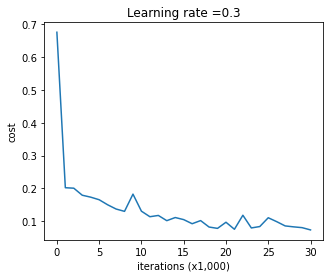

On the training set:
Accuracy: 0.966824644549763
On the test set:
Accuracy: 0.9099999999999998


In [122]:
activation_funcs = ["relu", "relu", "sigmoid"]
dnn = DeepNN([train_x.shape[0], 20, 3, 1], activation_funcs)
dnn.train(train_x, train_y, 30000, 0.3)

dnn.plot_lr()
print ("On the training set:")
predictions_train = dnn.predict(train_x, train_y)
print ("On the test set:")
predictions_test = dnn.predict(test_x, test_y)

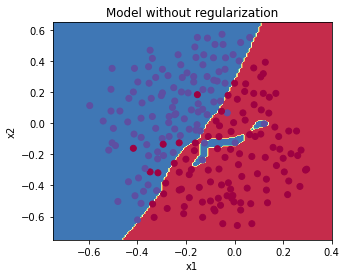

In [123]:
plt.title("Model without regularization")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(lambda x: predict_plot(dnn, x.T), train_x, train_y)

### Testing with L2 reg:

W 1  shape:  (20, 2)
b 1  shape:  (20, 1)
W 2  shape:  (3, 20)
b 2  shape:  (3, 1)
W 3  shape:  (1, 3)
b 3  shape:  (1, 1)
cost after iteration  0 :  0.749474203190544
cost after iteration  1000 :  0.24915509964218177
cost after iteration  2000 :  0.2384823341242372
cost after iteration  3000 :  0.2266840558838923
cost after iteration  4000 :  0.2233912905997334
cost after iteration  5000 :  0.21720590031454162
cost after iteration  6000 :  0.2174745626597327
cost after iteration  7000 :  0.2137160321251564
cost after iteration  8000 :  0.21333194096539426
cost after iteration  9000 :  0.21805972837732182
cost after iteration  10000 :  0.21382871981148444
cost after iteration  11000 :  0.21434383003339394
cost after iteration  12000 :  0.21389483380555038
cost after iteration  13000 :  0.21240073142488655
cost after iteration  14000 :  0.2133291084462723
cost after iteration  15000 :  0.2122753437001405
cost after iteration  16000 :  0.21272618403299393
cost after iteration  17000 :  0

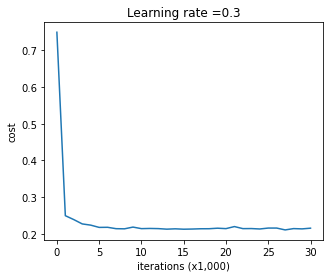

On the training set:
Accuracy: 0.9289099526066351
On the test set:
Accuracy: 0.9549999999999998


In [124]:
activation_funcs = ["relu", "relu", "sigmoid"]
dnn = DeepNN([train_x.shape[0], 20, 3, 1], activation_funcs)
dnn.train(train_x, train_y, 30000, 0.3, "L2", 0.2)

dnn.plot_lr()
print ("On the training set:")
predictions_train = dnn.predict(train_x, train_y)
print ("On the test set:")
predictions_test = dnn.predict(test_x, test_y)

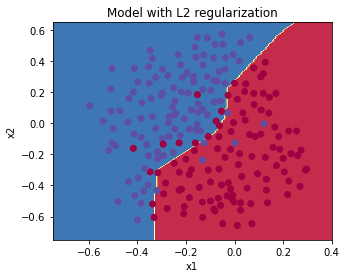

In [125]:
plt.title("Model with L2 regularization")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(lambda x: predict_plot(dnn, x.T), train_x, train_y)

# Dropout Regularization

In [130]:
class DeepNN:
    
    def __init__(self, layer_dims, actv_funcs):
        self.layer_dims = layer_dims
        self.L = len(self.layer_dims) # number of layers
        self.actv_funcs = actv_funcs # len = L-1

        assert not len(actv_funcs)>(self.L-1), "Too many activation function is given."
        assert not len(actv_funcs)<(self.L-1), "Too few activation function is given."
        assert not self.layer_dims[self.L-1]!=1, "This network only supports single layer output."
        
        self.params = self.create_parameters()     
        self.costs = []
        
    def create_parameters(self): 
        # np.random.seed(3)

        params = {}
        for l in range(1, self.L):
            if self.actv_funcs[l-1]=="relu":
                params["W"+str(l)] = 2 * np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
            elif self.actv_funcs[l-1]=="sigmoid":
                params["W"+str(l)] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
            else: 
                params["W"+str(l)] = np.random.randn(self.layer_dims[l], self.layer_dims[l-1]) / np.sqrt(self.layer_dims[l-1])
                
            params["b"+str(l)] = np.zeros((self.layer_dims[l], 1))
            print("W", l, " shape: ", params["W"+str(l)].shape)
            print("b", l, " shape: ", params["b"+str(l)].shape)

        # print(params)
        # sys.exit()
        
        return params

    def forward_test(self, X):
        linear_actvs = {}
        linear_actvs["A0"] = X
        for l in range(1, self.L): 
            linear_actvs["Z"+str(l)] = np.dot(self.params["W"+str(l)], linear_actvs["A"+str(l-1)]) + self.params["b"+str(l)]
            linear_actvs["A"+str(l)] = self.act_func(linear_actvs["Z"+str(l)], func = self.actv_funcs[l-1])

        return linear_actvs
    
    
    def forward(self, X, iter_num=-1):
        # np.random.seed(1)

        linear_actvs = {}
        # X.shape should be (layer_dim[0], m)
        # m = #training examples
        linear_actvs["A0"] = X

        if self.regularization == "dropout":
            for l in range(1, self.L): 
                linear_actvs["Z"+str(l)] = np.dot(self.params["W"+str(l)], linear_actvs["A"+str(l-1)]) + self.params["b"+str(l)]
                linear_actvs["A"+str(l)] = self.act_func(linear_actvs["Z"+str(l)], func = self.actv_funcs[l-1])

                # inverted dropout:
                # self.keep_probs is length of L-2 but layers are length of L
                if l < self.L-1:
                    curr_keep_prob = self.keep_probs[l-1]
                    linear_actvs["d"+str(l)] = (np.random.rand(linear_actvs["A"+str(l)].shape[0], linear_actvs["A"+str(l)].shape[1]) < curr_keep_prob).astype(int)
                    # print("d", l, " sum (iter={}):".format(iter_num), np.sum(linear_actvs["d"+str(l)]))
                    # print(np.sum(linear_actvs["d"+str(l)]) / (linear_actvs["d"+str(l)].shape[0]*linear_actvs["d"+str(l)].shape[1]))
                    linear_actvs["A"+str(l)] = np.multiply(linear_actvs["A"+str(l)], linear_actvs["d"+str(l)])
                    linear_actvs["A"+str(l)] = linear_actvs["A"+str(l)] / curr_keep_prob
            
        else:

            for l in range(1, self.L): 
                linear_actvs["Z"+str(l)] = np.dot(self.params["W"+str(l)], linear_actvs["A"+str(l-1)]) + self.params["b"+str(l)]
                linear_actvs["A"+str(l)] = self.act_func(linear_actvs["Z"+str(l)], func = self.actv_funcs[l-1])
        
        # print(linear_actvs["d2"])
        # sys.exit()
        
        return linear_actvs
        
    def backward(self, Y, linear_actvs, loss_func="add later"):
        grads = {}
        m = Y.shape[1]
        
        grads["dZ"+str(self.L-1)] = linear_actvs["A"+str(self.L-1)] - Y
        
        # from l = L-1 to l = 1
        for l in range(self.L-1, 0, -1):

            if self.regularization == "L2":
                # dW[l] = 1/m * dZ[l] . A[l-1] + lambda/m * W[l]
                grads["dW"+str(l)]   = 1/m * np.dot(grads["dZ"+str(l)], linear_actvs["A"+str(l-1)].T) + ((self.reg_param/m) * self.params["W"+str(l)])
                # db[l] = 1/m * np sum (dZ_l)
                grads["db"+str(l)]   = 1/m * np.sum(grads["dZ"+str(l)], axis=1, keepdims=True)
                if l!=1:
                    # dA[l-1] = (W[l]).T . dZ[l]
                    grads["dA"+str(l-1)] = np.dot((self.params["W"+str(l)]).T, grads["dZ"+str(l)])
                    # dZ[l-1] = dA[l-1] * g`
                    grads["dZ"+str(l-1)] = np.multiply(grads["dA"+str(l-1)], self.act_func(linear_actvs["Z"+str(l-1)], func=self.actv_funcs[l-2], grad=True))
            
            elif self.regularization == "dropout":
                # dW[l] = 1/m * dZ[l] . A[l-1] 
                grads["dW"+str(l)]   = 1/m * np.dot(grads["dZ"+str(l)], linear_actvs["A"+str(l-1)].T)
                # db[l] = 1/m * np sum (dZ_l)
                grads["db"+str(l)]   = 1/m * np.sum(grads["dZ"+str(l)], axis=1, keepdims=True)
                if l!=1:
                    # dA[l-1] = (W[l]).T . dZ[l]
                    grads["dA"+str(l-1)] = np.dot((self.params["W"+str(l)]).T, grads["dZ"+str(l)])
                    
                    # inverted dropout effect in back prop:
                    grads["dA"+str(l-1)] = np.multiply(grads["dA"+str(l-1)], linear_actvs["d"+str(l-1)])
                    curr_keep_prob =  self.keep_probs[l-2] 
                    grads["dA"+str(l-1)] = grads["dA"+str(l-1)] / curr_keep_prob
                    # print("in back prob, dropout: ", self.keep_probs, curr_keep_prob, l-1)

                    # dZ[l-1] = dA[l-1] * g`
                    # print("l-1 = ", l-1, ", func = ", self.actv_funcs[l-2])
                    grads["dZ"+str(l-1)] = np.multiply(grads["dA"+str(l-1)], self.act_func(linear_actvs["Z"+str(l-1)], func=self.actv_funcs[l-2], grad=True))

            else:
                # dW[l] = 1/m * dZ[l] . A[l-1] 
                grads["dW"+str(l)]   = 1/m * np.dot(grads["dZ"+str(l)], linear_actvs["A"+str(l-1)].T)
                # db[l] = 1/m * np sum (dZ_l)
                grads["db"+str(l)]   = 1/m * np.sum(grads["dZ"+str(l)], axis=1, keepdims=True)
                if l!=1:
                    # dA[l-1] = (W[l]).T . dZ[l]
                    grads["dA"+str(l-1)] = np.dot((self.params["W"+str(l)]).T, grads["dZ"+str(l)])
                    # dZ[l-1] = dA[l-1] * g`
                    grads["dZ"+str(l-1)] = np.multiply(grads["dA"+str(l-1)], self.act_func(linear_actvs["Z"+str(l-1)], func=self.actv_funcs[l-2], grad=True))

        # sys.exit()
        return grads
    
    def compute_cost(self, Y, linear_actvs, iter_num, is_debug=False):
        m = Y.shape[1]
        AL = linear_actvs["A"+str(self.L-1)]
            
        cost = (-1/m) * (np.nansum(np.multiply(Y, np.log(AL))) + np.nansum(np.multiply((1-Y), np.log(1-AL)))) 

        if self.regularization == "L2":
            reg_cost = 0
            for l in range(self.L-1, 0, -1):
                reg_cost += np.nansum(np.square(self.params['W'+str(l)]))

            cost = cost + self.reg_param/(2*m) * reg_cost
            cost = np.squeeze(cost)
        # else:

        return cost

    def update_params(self, grads, lr):
        for l in range(1, self.L):
            self.params["W"+str(l)] = self.params["W"+str(l)] - lr * grads["dW"+str(l)]
            self.params["b"+str(l)] = self.params["b"+str(l)] - lr * grads["db"+str(l)]
                
    def train(self, X, Y, num_iterations, lr, regularization = "", reg_param = 0, keep_probs = [1], is_debug=False):
        self.reg_param = reg_param
        self.learning_rate = lr
        self.regularization = regularization
        self.keep_probs = keep_probs
        if regularization == "L2":
            assert reg_param != 0, "L2 regularization requires reg_param"
            assert len(keep_probs)==0, "Cannot use dropout and L2 at the same time"
        elif regularization == "dropout":
            assert len(keep_probs)>0, "Dropout regularization requires Keep_prob list"
            assert reg_param == 0, "Cannot use dropout and L2 at the same time"
        
        m = X.shape[1] # ?
        assert not X.shape[0]!=self.layer_dims[0], "given Input X doesnt match the Input Layer size."
        assert not X.shape[1]!=Y.shape[1], "Number of inputs and outputs doesnt match."
        assert not Y.shape[0]!= 1, "This network only supports single output."
        assert not len(keep_probs) > self.L - 2, "wrong size of keep probs (input layer and output layer(last layer) doesn,t have keep_prob)"
        assert max(keep_probs) <= 1 and min(keep_probs) > 0, " 0 < keep prob <= 1"
        
        for i in range(num_iterations):
            
            linear_actvs = self.forward(X, i)
            grads = self.backward(Y, linear_actvs)
            
            cost = self.compute_cost(Y, linear_actvs, i, is_debug)
            self.update_params(grads, lr)
            
            if i % 1000 == 0 or i == num_iterations-1:
                print("cost after iteration ", i, ": ", cost)
        
            if i % 1000 == 0 or i == num_iterations-1:
                self.costs.append(cost)
                
                
    def predict(self, X, y):
        assert not X.shape[1]!=y.shape[1], "Number of inputs and outputs doesnt match."
        assert not X.shape[0]!=self.layer_dims[0], "given Input X doesnt match the Input Layer size."
        assert not y.shape[0]!=1, "This network only supports single layer output."

        m = X.shape[1]
        n = len(self.params) // 2 
        p = np.zeros((1,m))

        linear_actvs = {}
        linear_actvs["A0"] = X
        for l in range(1, self.L): 
            linear_actvs["Z"+str(l)] = np.dot(self.params["W"+str(l)], linear_actvs["A"+str(l-1)]) + self.params["b"+str(l)]
            linear_actvs["A"+str(l)] = self.act_func(linear_actvs["Z"+str(l)], func = self.actv_funcs[l-1])
            
        yhat = linear_actvs["A"+str(n)]

        for i in range(0, yhat.shape[1]):
            if yhat[0,i] > 0.5:
                p[0,i] = 1
            else:
                p[0,i] = 0
    
        print("Accuracy: "  + str(np.sum((p == y)/m)))

        return p
    
    def act_func(self, Z, func = "relu", grad=False):
        if func == "relu":
            if grad==False:
                return np.maximum(Z, 0)
            else:
                return np.where(Z <= 0, 0, 1)
            
        elif func == "sigmoid":
            if grad==False:
                res = 1/(1+np.exp(-Z))
                return res
            else: 
                s = 1/(1+np.exp(-Z))
                return s * (1-s)
        else:
            assert False, "Activation function "+func+" is not supported."
            
    def plot_lr(self):
        costs = np.squeeze(self.costs)
        plt.plot(costs)
        plt.ylabel('cost')
        plt.xlabel('iterations (x1,000)')
        plt.title("Learning rate =" + str(self.learning_rate))
        plt.show()

In [131]:
#train_x = train_x[:, 0:10]
#train_y = train_y[:, 0:10]
train_x.shape

(2, 211)

W 1  shape:  (20, 2)
b 1  shape:  (20, 1)
W 2  shape:  (3, 20)
b 2  shape:  (3, 1)
W 3  shape:  (1, 3)
b 3  shape:  (1, 1)
cost after iteration  0 :  0.6989604954729144
cost after iteration  1000 :  0.2713951625363846
cost after iteration  2000 :  0.2580334769669231
cost after iteration  3000 :  0.20277130769025467
cost after iteration  4000 :  0.2104263121689155
cost after iteration  5000 :  0.21884466712245695
cost after iteration  6000 :  0.22932140069740117
cost after iteration  7000 :  0.22189158876231438
cost after iteration  8000 :  0.23552224054707618
cost after iteration  9000 :  0.19785268650435883
cost after iteration  10000 :  0.17485234637914399
cost after iteration  11000 :  0.20365150880106636


F:\apps\Anaconda\lib\site-packages\ipykernel_launcher.py:137: RuntimeWarning: divide by zero encountered in log
F:\apps\Anaconda\lib\site-packages\ipykernel_launcher.py:137: RuntimeWarning: invalid value encountered in multiply


cost after iteration  12000 :  0.21725250822116568
cost after iteration  13000 :  0.2042425985962002
cost after iteration  14000 :  0.1773069948027382
cost after iteration  15000 :  0.20508360788702826
cost after iteration  16000 :  0.18241597362887074
cost after iteration  17000 :  0.16833818734483652
cost after iteration  18000 :  0.17733432779797204
cost after iteration  19000 :  0.16055661297096727
cost after iteration  20000 :  0.19913306635146433
cost after iteration  21000 :  0.19397923014229787
cost after iteration  22000 :  0.16794887032662528
cost after iteration  23000 :  0.1725592188562162
cost after iteration  24000 :  0.1798164218997807
cost after iteration  25000 :  0.18031602743847
cost after iteration  26000 :  0.1927643251686782
cost after iteration  27000 :  0.21370316885575666
cost after iteration  28000 :  0.17925719517297783
cost after iteration  29000 :  0.16428128188377852
cost after iteration  29999 :  0.16257353059633753


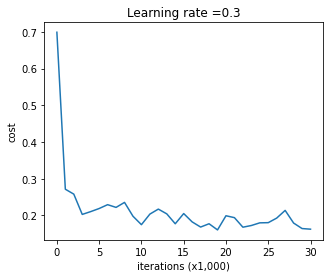

On the training set:
Accuracy: 0.9431279620853081
On the test set:
Accuracy: 0.9249999999999998


In [132]:
activation_funcs = ["relu", "relu", "sigmoid"]
dnn = DeepNN([train_x.shape[0], 20, 3, 1], activation_funcs)
# def train(self, X, Y, num_iterations, lr, regularization = "", reg_param = 0, keep_probs = [], is_debug=False)
dnn.train(train_x, train_y, 30000, 0.3, "dropout", 0, [0.83, 0.83])

dnn.plot_lr()
print ("On the training set:")
predictions_train = dnn.predict(train_x, train_y)
print ("On the test set:")
predictions_test = dnn.predict(test_x, test_y)

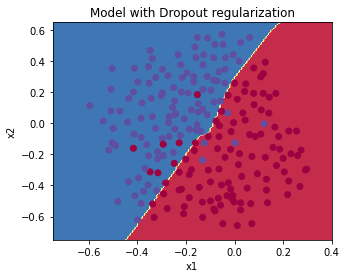

In [133]:
plt.title("Model with Dropout regularization")
axes = plt.gca()
axes.set_xlim([-0.75,0.40])
axes.set_ylim([-0.75,0.65])
plot_decision_boundary(lambda x: predict_plot(dnn, x.T), train_x, train_y)

# Early Stopping

In [378]:
# Add later

# Data Augmentation

y = 1. It's a cat picture.


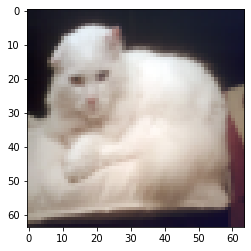

In [134]:
train_x_orig, train_y, test_x_orig, test_y, classes = load_cat_data()
# Example of a picture
index = 13
plt.imshow(train_x_orig[index])
print ("y = " + str(train_y[0,index]) + ". It's a " + classes[train_y[0,index]].decode("utf-8") +  " picture.")

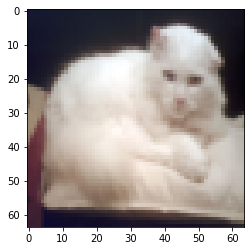

In [135]:
plt.imshow(np.flip(train_x_orig, 2)[index])

In [136]:
# Reshape the training and test examples
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0], -1).T   # The "-1" makes reshape flatten the remaining dimensions
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1).T

train_x_vertical_flip = np.flip(train_x_orig, 2)
train_x_vertical_flip_flatten = train_x_vertical_flip.reshape(train_x_vertical_flip.shape[0], -1).T

train_x_flatten = np.append(train_x_flatten, train_x_vertical_flip_flatten, axis=1)
train_y = np.append(train_y, train_y, axis=1)
# Standardize data to have feature values between 0 and 1.
train_x = train_x_flatten/255.
test_x = test_x_flatten/255.

print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

train_x's shape: (12288, 418)
test_x's shape: (12288, 50)


# Training with simple model:


W 1  shape:  (10, 12288)
b 1  shape:  (10, 1)
W 2  shape:  (5, 10)
b 2  shape:  (5, 1)
W 3  shape:  (1, 5)
b 3  shape:  (1, 1)
cost after iteration  0 :  0.6751789069288748
cost after iteration  1000 :  0.616425998234586
cost after iteration  2000 :  0.48240110735447594
cost after iteration  3000 :  0.3467559193945818
cost after iteration  4000 :  0.1238602187911333
cost after iteration  4499 :  0.07941360362789578


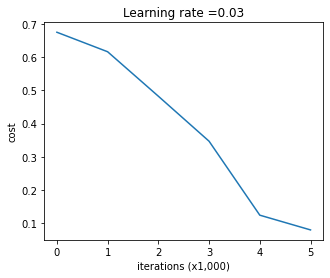

On the training set:
Accuracy: 0.9904306220095692
On the test set:
Accuracy: 0.72


In [203]:
activation_funcs = ["sigmoid", "sigmoid", "sigmoid"]
dnn = DeepNN([12288, 10, 5, 1], activation_funcs)
dnn.train(train_x, train_y, 4500, 0.03)

dnn.plot_lr()
print ("On the training set:")
predictions_train = dnn.predict(train_x, train_y)
print ("On the test set:")
predictions_test = dnn.predict(test_x, test_y)

# Training with L2 regularization:

W 1  shape:  (20, 12288)
b 1  shape:  (20, 1)
W 2  shape:  (10, 20)
b 2  shape:  (10, 1)
W 3  shape:  (5, 10)
b 3  shape:  (5, 1)
W 4  shape:  (1, 5)
b 4  shape:  (1, 1)
cost after iteration  0 :  0.8987188812923598
cost after iteration  1000 :  0.3732684176419
cost after iteration  1499 :  0.19425440214655298


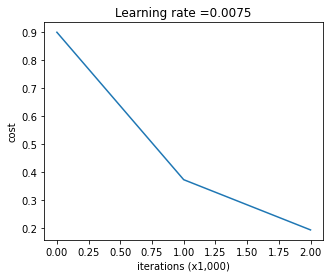

On the training set:
Accuracy: 0.9856459330143539
On the test set:
Accuracy: 0.74


In [198]:
activation_funcs = ["relu", "relu", "relu", "sigmoid"]
dnn = DeepNN([12288, 20, 10, 5, 1], activation_funcs)
dnn.train(train_x, train_y, 1500, 0.0075, reg_param=0.8)

dnn.plot_lr()
print ("On the training set:")
predictions_train = dnn.predict(train_x, train_y)
print ("On the test set:")
predictions_test = dnn.predict(test_x, test_y)

# Testing with dropout:

W 1  shape:  (20, 12288)
b 1  shape:  (20, 1)
W 2  shape:  (10, 20)
b 2  shape:  (10, 1)
W 3  shape:  (5, 10)
b 3  shape:  (5, 1)
W 4  shape:  (1, 5)
b 4  shape:  (1, 1)
cost after iteration  0 :  0.9043230752264199
cost after iteration  1000 :  0.46379774698629717
cost after iteration  1499 :  0.14716821609028208


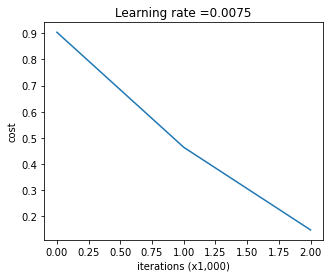

On the training set:
Accuracy: 0.9880382775119616
On the test set:
Accuracy: 0.78


In [196]:
activation_funcs = ["relu", "relu", "relu", "sigmoid"]
dnn = DeepNN([12288, 20, 10, 5, 1], activation_funcs)
dnn.train(train_x, train_y, 1500, 0.0075, "dropout", 0, [0.85, 0.85, 0.85])

dnn.plot_lr()
print ("On the training set:")
predictions_train = dnn.predict(train_x, train_y)
print ("On the test set:")
predictions_test = dnn.predict(test_x, test_y)

# Gradient Checking

In [ ]:
# Add later

# Mini Batch Gradient Descent

In [ ]:
# a function to create leist of minibatches, then use this function in train function of model

# Momentum

In [ ]:
# gradient descent with momentum

# RMSprop

# Adam optimization

# Learning rate Decay

# Appropiate SCALE to tune hyperparameters ? 

# Batch Normalization ****

# Multiclass classification, Softmax Regression